In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv(r"D:\python1\Week-9.1-Machine-Learning-Data-Science-Capstone-SLA-Prediction-Project\2.Data preprocessing\preprocessed_data.csv")

In [3]:
dataset

,Incident_ID,Incident_Type,Priority,Assigned_Department,Location,Status,Resolution_Type,Resolution_Time_Hours,Hour,Day,Month,SLA_Limit,SLA_Breached
0,INC100000,Network Outage,Low,Security Team,Data Center B,Resolved,Reboot,18.0,4,6,3,24,0
1,INC100001,Database Failure,Low,Database Admin,Remote Site 1,Resolved,Reboot,35.0,20,3,1,24,0
2,INC100002,Server Crash,Medium,Database Admin,Remote Site 2,Closed,Patch Applied,72.0,1,2,1,12,1
3,INC100003,Database Failure,Critical,Network Team,Remote Site 1,Resolved,Reboot,36.0,3,5,7,4,1
4,INC100004,Server Crash,Critical,Security Team,Head Office,Resolved,Configuration Fix,28.0,1,4,2,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,INC101195,Application Bug,Critical,Security Team,Remote Site 2,Resolved,Hardware Replacement,47.0,13,4,10,4,1
1196,INC101196,Security Breach,Low,Network Team,Data Center B,Resolved,Reboot,25.0,17,4,1,24,1
1197,INC101197,Network Outage,Medium,IT Support,Data Center B,Resolved,Patch Applied,19.0,5,3,6,12,1
1198,INC101198,Application Bug,Medium,IT Support,Head Office,Closed,Patch Applied,60.0,17,3,9,12,1


In [4]:
dataset.dtypes

Incident_ID               object
Incident_Type             object
Priority                  object
Assigned_Department       object
Location                  object
Status                    object
Resolution_Type           object
Resolution_Time_Hours    float64
Hour                       int64
Day                        int64
Month                      int64
SLA_Limit                  int64
SLA_Breached               int64
dtype: object

In [5]:
numeric=dataset.select_dtypes(include=["float"]).columns

In [7]:
dataset[numeric]

,Resolution_Time_Hours
0,18.0
1,35.0
2,72.0
3,36.0
4,28.0
...,...
1195,47.0
1196,25.0
1197,19.0
1198,60.0


In [10]:
categorical=dataset.select_dtypes(include=["object","float"]).columns

In [11]:
categorical

Index(['Incident_ID', 'Incident_Type', 'Priority', 'Assigned_Department',
       'Location', 'Status', 'Resolution_Type', 'Resolution_Time_Hours'],
      dtype='object')

# Frequency table 

In [12]:
for columnname in categorical :
     frequency_table=pd.DataFrame(columns=["Unique_values","Frequency","Relative_Frequency","cusum"])

In [13]:
frequency_table

,Unique_values,Frequency,Relative_Frequency,cusum


In [14]:
freq = dataset[columnname].value_counts()

In [15]:
freq

Resolution_Time_Hours
20.0    25
39.0    25
62.0    24
22.0    24
18.0    23
        ..
32.0    11
42.0    11
55.0    10
38.0     8
0.0      2
Name: count, Length: 73, dtype: int64

In [16]:
def freq_table(dataset):

    result = {}

    for columnname in categorical:

        freq = dataset[columnname].value_counts()

        freqTable = pd.DataFrame({
            "Unique_Values": freq.index,
            "Frequency": freq.values,
            "Relative Frequency": freq.values / len(dataset),
            'Cumulative Frequency': freq.cumsum(),
            "Percentage": (freq.values / len(dataset)) * 100
        })

        result[columnname] = freqTable

    return result

In [18]:
freq_table(dataset)

{'Incident_ID':             Unique_Values  Frequency  Relative Frequency  \
 Incident_ID                                                
 INC101199       INC101199          1            0.000833   
 INC100000       INC100000          1            0.000833   
 INC100001       INC100001          1            0.000833   
 INC100002       INC100002          1            0.000833   
 INC100003       INC100003          1            0.000833   
 ...                   ...        ...                 ...   
 INC100019       INC100019          1            0.000833   
 INC100020       INC100020          1            0.000833   
 INC100021       INC100021          1            0.000833   
 INC100022       INC100022          1            0.000833   
 INC100023       INC100023          1            0.000833   
 
              Cumulative Frequency  Percentage  
 Incident_ID                                    
 INC101199                       1    0.083333  
 INC100000                       2    0.083

# Central Tendency

In [19]:
descriptive = pd.DataFrame(
    index=[
        "Mean",
        "Median",
        "Mode",
        "Q1:25%",
        "Q2:50%",
        "Q3:75%",
        "IQR",
        "1.5 Rule",
        "Lower Limit",
        "Upper Limit",
        "Outlier Count",
        "Standard deviation",
        "Minimum",
        "Maximum",
        "Frequency counts"
    ],
    columns=numeric
)

In [20]:
descriptive

,Resolution_Time_Hours
Mean,NaN
Median,NaN
Mode,NaN
Q1:25%,NaN
Q2:50%,NaN
Q3:75%,NaN
IQR,NaN
1.5 Rule,NaN
Lower Limit,NaN
Upper Limit,NaN


In [21]:
for cols in numeric:

    descriptive.loc["Mean", cols] = dataset[cols].mean()

    descriptive.loc["Median", cols] = dataset[cols].median()

    descriptive.loc["Mode", cols] = dataset[cols].mode()[0]

    # Quartiles
    descriptive.loc["Q1:25%", cols] = dataset[cols].quantile(0.25)

    descriptive.loc["Q2:50%", cols] = dataset[cols].quantile(0.50)

    descriptive.loc["Q3:75%", cols] = dataset[cols].quantile(0.75)

    # IQR
    descriptive.loc["IQR", cols] = (descriptive.loc["Q3:75%", cols]-descriptive.loc["Q1:25%", cols])

    # 1.5 Rule
    descriptive.loc["1.5 Rule", cols] = (1.5 * descriptive.loc["IQR", cols])

    # Lower Boundary
    descriptive.loc["Lower Limit", cols] = (descriptive.loc["Q1:25%", cols]-descriptive.loc["1.5 Rule", cols])

    # Upper Boundary
    descriptive.loc["Upper Limit", cols] = (descriptive.loc["Q3:75%", cols]+descriptive.loc["1.5 Rule", cols])

    # Outliers
    lower = descriptive.loc["Lower Limit", cols]

    upper = descriptive.loc["Upper Limit", cols]

    outliers = dataset[
        (dataset[cols] < lower) |
        (dataset[cols] > upper)
    ][cols]

    descriptive.loc["Outlier Count", cols] = len(outliers)

    # Other Statistics
    descriptive.loc["Standard deviation", cols] = dataset[cols].std()

    descriptive.loc["Minimum", cols] = dataset[cols].min()

    descriptive.loc["Maximum", cols] = dataset[cols].max()

    descriptive.loc["Frequency counts", cols] = str(dataset[cols].value_counts().head().to_dict()
    )

In [22]:
descriptive

,Resolution_Time_Hours
Mean,35.961667
Median,35.0
Mode,20.0
Q1:25%,18.0
Q2:50%,35.0
Q3:75%,55.0
IQR,37.0
1.5 Rule,55.5
Lower Limit,-37.5
Upper Limit,110.5


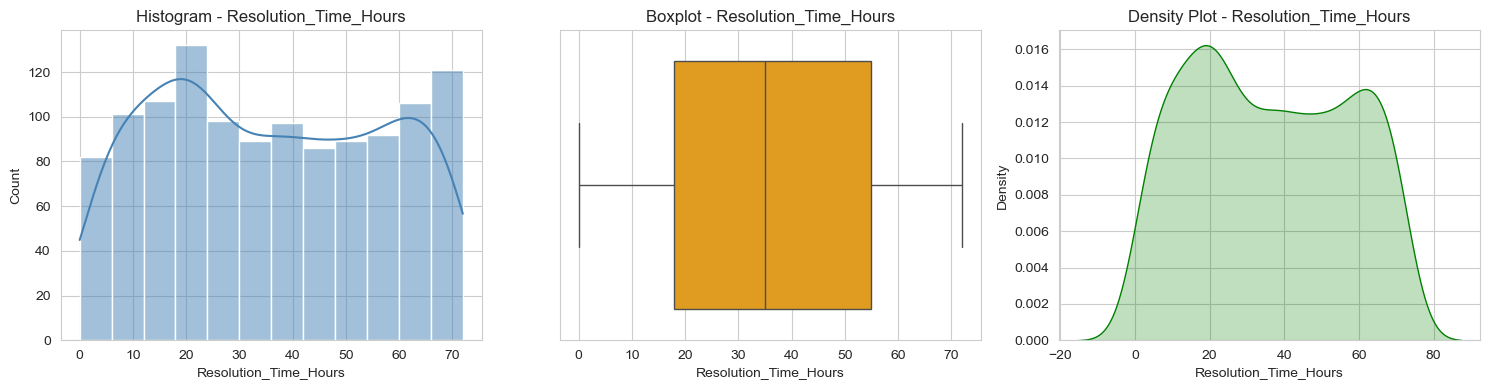

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

for col in numeric:
    plt.figure(figsize=(15,4))

    # Histogram
    plt.subplot(1,3,1)
    sns.histplot(dataset[col], kde=True, color="steelblue")
    plt.title(f'Histogram - {col}')

    # Boxplot
    plt.subplot(1,3,2)
    sns.boxplot(x=dataset[col], color="orange")
    plt.title(f'Boxplot - {col}')

    # KDE Plot
    plt.subplot(1,3,3)
    sns.kdeplot(dataset[col], fill=True, color="green")
    plt.title(f'Density Plot - {col}')

    plt.tight_layout()
    plt.show()